
# Proposal-aligned Rényi-2 Binder calculation at fixed \(\lambda=0.7\)

This notebook studies the interior phase-diagram slice

\[
\delta=0.7,\qquad
\lambda=0.7,
\]

so that

\[
\lambda_x=\delta\lambda=0.49,\qquad
\lambda_{zz}=\delta(1-\lambda)=0.21,
\]

while the two dephasing probabilities are scanned together:

\[
q_x=q_{zz}=q,\qquad 0\le q\le \frac12.
\]

Compared with the previous right-boundary notebook, this notebook includes
**both** weak-measurement layers:

1. weak \(X_i\) measurements;
2. \(X_i\) dephasing;
3. weak \(Z_iZ_{i+1}\) measurements;
4. \(Z_iZ_{i+1}\) dephasing.

The proposal Rényi-2 Binder is evaluated for every Born-sampled trajectory
using the replica-overlap MPO

\[
Q=\sum_i Z_i^{\mathrm{bra}}Z_i^{\mathrm{ket}},
\]

and the reported observable is

\[
\overline{B_2}=\frac{1}{N_{\rm traj}}\sum_m B_2(m).
\]

This notebook preserves the direct-correlator checks, bootstrap errors,
finite-size crossings, convergence checks, and export utilities of the
validated right-boundary notebook.


In [1]:

import Pkg

# Uncomment once if packages are missing:
# Pkg.add(["ITensors", "ITensorMPS", "DataFrames", "CSV", "Plots"])

using Random
using Statistics
using LinearAlgebra
using Printf
using Dates
using Test

using ITensors
using ITensorMPS
using DataFrames
using CSV
using Plots

println("Julia threads: ", Threads.nthreads())


Julia threads: 10



## Reproducible configuration

The initial state is

\[
\rho_0=
|\uparrow\cdots\uparrow\rangle
\langle\uparrow\cdots\uparrow|,
\]

which lies in the repetition-code sector.

The fixed slice is generated by

\[
\lambda_x=\delta\lambda,\qquad
\lambda_{zz}=\delta(1-\lambda),
\]

with \(\delta=0.7\) and \(\lambda=0.7\). Therefore,

\[
\lambda_x=0.49,\qquad \lambda_{zz}=0.21.
\]

The scan variable is the common dephasing probability

\[
q_x=q_{zz}=q.
\]


In [2]:

# ============================================================
# Proposal parameters and numerical defaults
# ============================================================

DELTA = 0.7
FIXED_LAMBDA = 0.7

FIXED_LAMBDA_X = DELTA * FIXED_LAMBDA
FIXED_LAMBDA_ZZ = DELTA * (1 - FIXED_LAMBDA)

DYN_MAXDIM = 256
DYN_CUTOFF = 1e-12
OBS_MAXDIM_FACTOR = 4
OBS_CUTOFF = 1e-14

BOUNDARY = :open
@assert BOUNDARY in (:open,)

RUN_QUICK_SCAN = true
RUN_PRODUCTION_SCAN = false

function proposal_parameters(lambda::Real, q::Real; delta::Real=DELTA)
    @assert 0.0 <= lambda <= 1.0
    @assert 0.0 <= q <= 0.5
    @assert 0.0 < delta < 1.0

    return (
        lambda=Float64(lambda),
        delta=Float64(delta),
        lambda_x=Float64(delta * lambda),
        lambda_zz=Float64(delta * (1 - lambda)),
        q=Float64(q),
        q_x=Float64(q),
        q_zz=Float64(q),
    )
end

fixed_slice_parameters(q::Real) =
    proposal_parameters(FIXED_LAMBDA, q; delta=DELTA)

@assert isapprox(FIXED_LAMBDA_X, 0.49; atol=1e-14)
@assert isapprox(FIXED_LAMBDA_ZZ, 0.21; atol=1e-14)

@show fixed_slice_parameters(0.10)


fixed_slice_parameters(0.1) = (lambda = 0.7, delta = 0.7, lambda_x = 0.48999999999999994, lambda_zz = 0.21000000000000002, q = 0.1, q_x = 0.1, q_zz = 0.1)


(lambda = 0.7, delta = 0.7, lambda_x = 0.48999999999999994, lambda_zz = 0.21000000000000002, q = 0.1, q_x = 0.1, q_zz = 0.1)

In [3]:

# ============================================================
# Doubled-MPS utilities
# ============================================================

const sigma_x = Float64[0 1; 1 0]
const sigma_z = Float64[1 0; 0 -1]
const identity_2 = Matrix{Float64}(I, 2, 2)

function pair_mps(local_vec::AbstractVector, s_bra::Index, s_ket::Index)
    @assert length(local_vec) == 4
    return MPS(collect(local_vec), [s_bra, s_ket])
end

function product_density_mps(sites_in, local_vec::AbstractVector)
    sites = collect(sites_in)
    @assert iseven(length(sites))

    tensors = ITensor[]
    for n in 1:2:length(sites)
        pair = pair_mps(local_vec, sites[n], sites[n + 1])
        push!(tensors, pair[1], pair[2])
    end
    return MPS(tensors)
end

function bell_state(sites_in)
    # |I>> = product_i (|00> + |11>)
    return product_density_mps(
        collect(sites_in),
        [1.0, 0.0, 0.0, 1.0],
    )
end

function initial_repetition_code_state(sites_in)
    # |up ... up><up ... up|, a valid state in the repetition-code space.
    return product_density_mps(
        collect(sites_in),
        [1.0, 0.0, 0.0, 0.0],
    )
end

doubled_trace(rho::MPS, trace_bra::MPS) =
    real(inner(trace_bra, rho))

hilbert_schmidt_norm(rho::MPS) =
    real(inner(rho, rho))

function trace_normalize(
    rho::MPS,
    trace_bra::MPS;
    atol::Float64=1e-13,
)
    tr_rho = doubled_trace(rho, trace_bra)

    if !isfinite(tr_rho) || tr_rho <= atol
        error("Invalid density-matrix trace: Tr(rho) = $tr_rho")
    end

    return rho / tr_rho
end

function physical_bonds(L::Int; boundary::Symbol=BOUNDARY)
    @assert L >= 2
    boundary == :open || error("This notebook currently supports :open only.")
    return [(i, i + 1) for i in 1:(L - 1)]
end

function bond_dimension_or_one(rho::MPS, bond::Int)
    link = linkind(rho, bond)

    # ITensor returns `nothing` when two neighboring MPS tensors have no
    # explicit link Index. That represents a tensor-product bond and must
    # be interpreted as bond dimension 1.
    return isnothing(link) ? 1 : dim(link)
end

function max_interphysical_linkdim(rho::MPS, L::Int)
    L <= 1 && return 1

    return maximum(
        bond_dimension_or_one(rho, 2i)
        for i in 1:(L - 1)
    )
end


max_interphysical_linkdim (generic function with 1 method)


## Weak \(X\) measurements: exact Born sampling

For

\[
K_m^{X}=
\frac{I+(-1)^m\lambda_x X}
{\sqrt{2(1+\lambda_x^2)}},
\]

the code constructs both unnormalized post-measurement density matrices,
uses their traces as the two Born weights, samples one outcome, and then
normalizes the selected state.

This avoids assuming equal outcome probabilities.


In [4]:

# ============================================================
# Weak X measurement with analytic Born probabilities
# ============================================================

function bounded_pauli_expectation(
    rho::MPS,
    trace_bra::MPS,
    operator_gates;
    context::AbstractString,
    physical_tol::Float64=1e-7,
)
    input_trace = doubled_trace(rho, trace_bra)

    if !isfinite(input_trace) || input_trace <= 0
        error("$context: invalid input trace $input_trace.")
    end

    # operator_gates are one-site Pauli gates, so this contraction does not
    # require bond-dimension truncation.
    rho_with_operator = apply(operator_gates, rho)

    expectation =
        real(inner(trace_bra, rho_with_operator)) / input_trace

    if !isfinite(expectation)
        error("$context: non-finite Pauli expectation $expectation.")
    end

    if abs(expectation) > 1 + physical_tol
        error(
            "$context: unphysical Pauli expectation $expectation. " *
            "Increase maxdim and/or decrease cutoff."
        )
    end

    return clamp(expectation, -1.0, 1.0)
end

function binary_weak_measurement_probabilities(
    expectation::Real,
    lambda::Float64;
    context::AbstractString,
    probability_tol::Float64=1e-12,
)
    @assert 0.0 <= lambda <= 1.0

    coefficient = lambda / (1 + lambda^2)

    probabilities = Float64[
        0.5 + coefficient * expectation,
        0.5 - coefficient * expectation,
    ]

    if any(p -> !isfinite(p) || p < -probability_tol, probabilities)
        error(
            "$context: invalid analytic Born probabilities " *
            "$(probabilities)."
        )
    end

    probabilities = max.(probabilities, 0.0)
    probabilities ./= sum(probabilities)

    return probabilities
end

function x_measurement_probabilities(
    rho::MPS,
    sites,
    i::Int,
    lambda_x::Float64,
    trace_bra::MPS,
)
    bra_i = 2i - 1

    expectation = bounded_pauli_expectation(
        rho,
        trace_bra,
        [op(sigma_x, sites[bra_i])];
        context="X measurement at site $i",
    )

    probabilities = binary_weak_measurement_probabilities(
        expectation,
        lambda_x;
        context="X measurement at site $i",
    )

    return expectation, probabilities
end

function apply_selected_x_measurement(
    rho::MPS,
    sites,
    i::Int,
    lambda_x::Float64,
    outcome::Int;
    maxdim::Int,
    cutoff::Float64,
)
    @assert outcome in (0, 1)

    bra_i = 2i - 1
    ket_i = 2i

    K = (
        identity_2 + (-1)^outcome * lambda_x * sigma_x
    ) / sqrt(2 * (1 + lambda_x^2))

    K_bra = op(K, sites[bra_i])
    K_ket = op(conj(K), sites[ket_i])

    return apply(
        [K_bra, K_ket],
        rho;
        cutoff=cutoff,
        maxdim=maxdim,
    )
end

function apply_weak_x_measurement_site(
    rho::MPS,
    sites,
    i::Int,
    lambda_x::Float64,
    trace_bra::MPS,
    rng::AbstractRNG;
    maxdim::Int,
    cutoff::Float64,
)
    _, probabilities = x_measurement_probabilities(
        rho,
        sites,
        i,
        lambda_x,
        trace_bra,
    )

    selected_index =
        rand(rng) < probabilities[1] ? 1 : 2

    outcome = selected_index - 1

    rho_selected = apply_selected_x_measurement(
        rho,
        sites,
        i,
        lambda_x,
        outcome;
        maxdim=maxdim,
        cutoff=cutoff,
    )

    return (
        trace_normalize(rho_selected, trace_bra),
        outcome,
        probabilities,
    )
end

function apply_weak_x_layer(
    rho::MPS,
    sites,
    L::Int,
    lambda_x::Float64,
    trace_bra::MPS,
    rng::AbstractRNG;
    maxdim::Int,
    cutoff::Float64,
)
    outcomes = Vector{Int}(undef, L)

    for i in 1:L
        rho, outcomes[i], _ = apply_weak_x_measurement_site(
            rho,
            sites,
            i,
            lambda_x,
            trace_bra,
            rng;
            maxdim=maxdim,
            cutoff=cutoff,
        )
    end

    return rho, outcomes
end


apply_weak_x_layer (generic function with 1 method)


## Weak \(ZZ\) measurements: exact Born sampling

For every nearest-neighbor bond \((i,j)\),

\[
K_m^{ZZ}
=
\frac{
I+(-1)^m\lambda_{zz} Z_iZ_j
}{
\sqrt{2(1+\lambda_{zz}^2)}
}.
\]

The bra and ket factors are applied as two separate two-site gates:

\[
K_m^{ZZ}\otimes (K_m^{ZZ})^*.
\]

This avoids forming an unnecessary four-site gate. The two Born probabilities are evaluated analytically from the pre-measurement Pauli expectation value, and only the selected branch is applied to the MPS.


In [5]:

# ============================================================
# Weak ZZ measurement with analytic Born probabilities
# ============================================================

function zz_measurement_probabilities(
    rho::MPS,
    sites,
    i::Int,
    j::Int,
    lambda_zz::Float64,
    trace_bra::MPS,
)
    @assert j == i + 1

    bra_i = 2i - 1
    bra_j = 2j - 1

    # Z_i Z_j is applied as two one-site gates. This avoids any MPS
    # truncation in the probability calculation.
    expectation = bounded_pauli_expectation(
        rho,
        trace_bra,
        [
            op(sigma_z, sites[bra_i]),
            op(sigma_z, sites[bra_j]),
        ];
        context="ZZ measurement on bond ($i,$j)",
    )

    probabilities = binary_weak_measurement_probabilities(
        expectation,
        lambda_zz;
        context="ZZ measurement on bond ($i,$j)",
    )

    return expectation, probabilities
end

function apply_selected_zz_measurement(
    rho::MPS,
    sites,
    i::Int,
    j::Int,
    lambda_zz::Float64,
    outcome::Int;
    maxdim::Int,
    cutoff::Float64,
)
    @assert j == i + 1
    @assert outcome in (0, 1)

    bra_i, ket_i = 2i - 1, 2i
    bra_j, ket_j = 2j - 1, 2j

    identity_bra =
        op(identity_2, sites[bra_i]) *
        op(identity_2, sites[bra_j])

    zz_bra =
        op(sigma_z, sites[bra_i]) *
        op(sigma_z, sites[bra_j])

    identity_ket =
        op(conj(identity_2), sites[ket_i]) *
        op(conj(identity_2), sites[ket_j])

    zz_ket =
        op(conj(sigma_z), sites[ket_i]) *
        op(conj(sigma_z), sites[ket_j])

    normalization = sqrt(2 * (1 + lambda_zz^2))
    sign = (-1)^outcome

    K_bra =
        (identity_bra + sign * lambda_zz * zz_bra) /
        normalization

    K_ket =
        (identity_ket + sign * lambda_zz * zz_ket) /
        normalization

    # Only the selected branch is compressed.
    return apply(
        [K_bra, K_ket],
        rho;
        cutoff=cutoff,
        maxdim=maxdim,
    )
end

function apply_weak_zz_measurement_bond(
    rho::MPS,
    sites,
    i::Int,
    j::Int,
    lambda_zz::Float64,
    trace_bra::MPS,
    rng::AbstractRNG;
    maxdim::Int,
    cutoff::Float64,
)
    _, probabilities = zz_measurement_probabilities(
        rho,
        sites,
        i,
        j,
        lambda_zz,
        trace_bra,
    )

    selected_index =
        rand(rng) < probabilities[1] ? 1 : 2

    outcome = selected_index - 1

    rho_selected = apply_selected_zz_measurement(
        rho,
        sites,
        i,
        j,
        lambda_zz,
        outcome;
        maxdim=maxdim,
        cutoff=cutoff,
    )

    return (
        trace_normalize(rho_selected, trace_bra),
        outcome,
        probabilities,
    )
end

function apply_weak_zz_layer(
    rho::MPS,
    sites,
    L::Int,
    lambda_zz::Float64,
    trace_bra::MPS,
    rng::AbstractRNG;
    maxdim::Int,
    cutoff::Float64,
    boundary::Symbol=BOUNDARY,
)
    bonds = physical_bonds(L; boundary=boundary)
    outcomes = Vector{Int}(undef, length(bonds))

    for (n, (i, j)) in enumerate(bonds)
        rho, outcomes[n], _ = apply_weak_zz_measurement_bond(
            rho,
            sites,
            i,
            j,
            lambda_zz,
            trace_bra,
            rng;
            maxdim=maxdim,
            cutoff=cutoff,
        )
    end

    return rho, outcomes
end


apply_weak_zz_layer (generic function with 1 method)


## Both measurement and both dephasing layers are active

At \(\lambda=0.7\), neither measurement strength vanishes:

\[
\lambda_x=0.49,\qquad \lambda_{zz}=0.21.
\]

A full time step is

\[
\mathcal M_X
\longrightarrow
\mathcal D_X
\longrightarrow
\mathcal M_{ZZ}
\longrightarrow
\mathcal D_{ZZ}.
\]

The weak \(ZZ\) outcomes are sampled conditionally, bond by bond, from their
Born probabilities. Since all nearest-neighbor \(ZZ\) measurement operators
commute, the exact joint distribution can be generated by this sequential
conditional sampling; finite MPS truncation is the only source of order
dependence.


In [6]:

# ============================================================
# X and ZZ dephasing superoperator gates
# ============================================================

function build_x_dephasing_gates(sites, L::Int, q_x::Float64)
    @assert 0.0 <= q_x <= 0.5

    gates = Vector{ITensor}(undef, L)

    for i in 1:L
        bra_i = 2i - 1
        ket_i = 2i

        identity_gate =
            op(identity_2, sites[bra_i]) *
            op(conj(identity_2), sites[ket_i])

        flip_gate =
            op(sigma_x, sites[bra_i]) *
            op(conj(sigma_x), sites[ket_i])

        gates[i] =
            (1 - q_x) * identity_gate +
            q_x * flip_gate
    end

    return gates
end

function build_zz_dephasing_gates(
    sites,
    L::Int,
    q_zz::Float64;
    boundary::Symbol=BOUNDARY,
)
    @assert 0.0 <= q_zz <= 0.5

    bonds = physical_bonds(L; boundary=boundary)
    gates = Vector{ITensor}(undef, length(bonds))

    for (n, (i, j)) in enumerate(bonds)
        bra_i, ket_i = 2i - 1, 2i
        bra_j, ket_j = 2j - 1, 2j

        identity_gate =
            op(identity_2, sites[bra_i]) *
            op(identity_2, sites[bra_j]) *
            op(conj(identity_2), sites[ket_i]) *
            op(conj(identity_2), sites[ket_j])

        zz_gate =
            op(sigma_z, sites[bra_i]) *
            op(sigma_z, sites[bra_j]) *
            op(conj(sigma_z), sites[ket_i]) *
            op(conj(sigma_z), sites[ket_j])

        gates[n] =
            (1 - q_zz) * identity_gate +
            q_zz * zz_gate
    end

    return gates
end

function apply_channel_layer(
    rho::MPS,
    gates::Vector{ITensor},
    trace_bra::MPS;
    maxdim::Int,
    cutoff::Float64,
)
    for gate in gates
        rho = apply(
            [gate],
            rho;
            cutoff=cutoff,
            maxdim=maxdim,
        )
    end

    # The exact channel preserves trace; this removes truncation drift only.
    return trace_normalize(rho, trace_bra)
end


apply_channel_layer (generic function with 1 method)

In [7]:

# ============================================================
# One Born-sampled trajectory at fixed lambda = 0.7
# ============================================================

function evolve_fixed_lambda_one_trial(
    L::Int;
    q::Float64,
    T_max::Int=4L,
    maxdim::Int=DYN_MAXDIM,
    cutoff::Float64=DYN_CUTOFF,
    seed::Union{Nothing,Int}=nothing,
    rng::AbstractRNG=isnothing(seed) ?
        Random.default_rng() : MersenneTwister(seed),
    boundary::Symbol=BOUNDARY,
)
    @assert L >= 2
    @assert 0.0 <= q <= 0.5
    @assert T_max >= 0

    params = fixed_slice_parameters(q)

    @assert isapprox(params.lambda, 0.7; atol=1e-14)
    @assert isapprox(params.lambda_x, 0.49; atol=1e-14)
    @assert isapprox(params.lambda_zz, 0.21; atol=1e-14)
    @assert params.q_x == params.q_zz && params.q_zz == params.q

    sites = siteinds("Qubit", 2L)
    trace_bra = bell_state(sites)

    rho = trace_normalize(
        initial_repetition_code_state(sites),
        trace_bra,
    )

    x_dephasing_gates =
        build_x_dephasing_gates(sites, L, params.q_x)

    zz_dephasing_gates =
        build_zz_dephasing_gates(
            sites,
            L,
            params.q_zz;
            boundary=boundary,
        )

    max_trace_error =
        abs(doubled_trace(rho, trace_bra) - 1.0)

    max_cross_site_bond =
        max_interphysical_linkdim(rho, L)

    for _ in 1:T_max
        # 1. Weak X measurements.
        rho, _ = apply_weak_x_layer(
            rho,
            sites,
            L,
            params.lambda_x,
            trace_bra,
            rng;
            maxdim=maxdim,
            cutoff=cutoff,
        )

        # 2. X dephasing.
        rho = apply_channel_layer(
            rho,
            x_dephasing_gates,
            trace_bra;
            maxdim=maxdim,
            cutoff=cutoff,
        )

        # 3. Weak ZZ measurements.
        rho, _ = apply_weak_zz_layer(
            rho,
            sites,
            L,
            params.lambda_zz,
            trace_bra,
            rng;
            maxdim=maxdim,
            cutoff=cutoff,
            boundary=boundary,
        )

        # 4. ZZ dephasing.
        rho = apply_channel_layer(
            rho,
            zz_dephasing_gates,
            trace_bra;
            maxdim=maxdim,
            cutoff=cutoff,
        )

        max_trace_error = max(
            max_trace_error,
            abs(doubled_trace(rho, trace_bra) - 1.0),
        )

        max_cross_site_bond = max(
            max_cross_site_bond,
            max_interphysical_linkdim(rho, L),
        )
    end

    return (
        rho=rho,
        sites=sites,
        trace_bra=trace_bra,
        params=params,
        boundary=boundary,
        max_trace_error=max_trace_error,
        max_interphysical_linkdim=max_cross_site_bond,
    )
end


evolve_fixed_lambda_one_trial (generic function with 1 method)


## Proposal \(B_2(m)\): replica-overlap order parameter

Define

\[
q_i=Z_iZ_i',\qquad
Q=\sum_{i=1}^{L}q_i.
\]

For a trajectory \(m\),

\[
M_2(m)=
\frac{\langle\!\langle\rho_m|Q^2|\rho_m\rangle\!\rangle}
{L^2\langle\!\langle\rho_m|\rho_m\rangle\!\rangle},
\]

\[
M_4(m)=
\frac{\langle\!\langle\rho_m|Q^4|\rho_m\rangle\!\rangle}
{L^4\langle\!\langle\rho_m|\rho_m\rangle\!\rangle},
\]

and

\[
B_2(m)=1-\frac{M_4(m)}{3M_2(m)^2}.
\]

The production implementation uses the \(Q\)-MPO. The direct correlator
implementation is retained only for small-\(L\) validation.


In [8]:

# ============================================================
# Proposal Rényi-2 moments and Binder
# ============================================================

function build_replica_overlap_mpo(sites, L::Int)
    os = OpSum()

    for i in 1:L
        os += 1.0, "Z", 2i - 1, "Z", 2i
    end

    return MPO(os, sites)
end

function binder_from_moments(
    M2::Real,
    M4::Real;
    tol::Float64=1e-13,
)
    if !isfinite(M2) || !isfinite(M4) || M2 <= tol
        return NaN
    end

    return 1.0 - M4 / (3.0 * M2^2)
end

function renyi2_binder_one_trajectory(
    rho::MPS,
    sites,
    L::Int;
    maxdim::Int=OBS_MAXDIM_FACTOR * DYN_MAXDIM,
    cutoff::Float64=OBS_CUTOFF,
    norm_tol::Float64=1e-14,
)
    Q = build_replica_overlap_mpo(sites, L)

    hs_norm = hilbert_schmidt_norm(rho)

    if !isfinite(hs_norm) || hs_norm <= norm_tol
        error("Invalid doubled-state norm: <rho|rho> = $hs_norm")
    end

    psi1 = apply(
        Q,
        rho;
        cutoff=cutoff,
        maxdim=maxdim,
    )

    psi2 = apply(
        Q,
        psi1;
        cutoff=cutoff,
        maxdim=maxdim,
    )

    numerator_2 = real(inner(psi1, psi1))
    numerator_4 = real(inner(psi2, psi2))

    M2 = numerator_2 / (L^2 * hs_norm)
    M4 = numerator_4 / (L^4 * hs_norm)
    B2 = binder_from_moments(M2, M4)

    return (
        M2=M2,
        M4=M4,
        B2=B2,
        purity=hs_norm,
        numerator_2=numerator_2,
        numerator_4=numerator_4,
    )
end


renyi2_binder_one_trajectory (generic function with 1 method)

In [9]:

# ============================================================
# Independent direct-correlator implementation for validation
# ============================================================

function replica_z_gates(sites, L::Int)
    return [
        op(sigma_z, sites[2i - 1]) *
        op(sigma_z, sites[2i])
        for i in 1:L
    ]
end

function renyi2_string_expectation(
    rho::MPS,
    q_gates::Vector{ITensor},
    active_sites::Vector{Int},
    hs_norm::Float64;
    maxdim::Int,
    cutoff::Float64,
)
    isempty(active_sites) && return 1.0

    gates = ITensor[q_gates[i] for i in active_sites]

    rho_O = apply(
        gates,
        rho;
        cutoff=cutoff,
        maxdim=maxdim,
    )

    return real(inner(rho, rho_O) / hs_norm)
end

function renyi2_moments_direct(
    rho::MPS,
    sites,
    L::Int;
    maxdim::Int=1024,
    cutoff::Float64=1e-14,
)
    hs_norm = hilbert_schmidt_norm(rho)
    hs_norm > 1e-14 || error("Doubled-state norm is too small.")

    q_gates = replica_z_gates(sites, L)

    pair_sum = 0.0
    for i in 1:(L - 1)
        for j in (i + 1):L
            pair_sum += renyi2_string_expectation(
                rho,
                q_gates,
                [i, j],
                hs_norm;
                maxdim=maxdim,
                cutoff=cutoff,
            )
        end
    end

    quad_sum = 0.0
    if L >= 4
        for i in 1:(L - 3)
            for j in (i + 1):(L - 2)
                for k in (j + 1):(L - 1)
                    for ell in (k + 1):L
                        quad_sum += renyi2_string_expectation(
                            rho,
                            q_gates,
                            [i, j, k, ell],
                            hs_norm;
                            maxdim=maxdim,
                            cutoff=cutoff,
                        )
                    end
                end
            end
        end
    end

    # Exact multiplicities from q_i^2 = I.
    M2 = (L + 2 * pair_sum) / L^2

    identity_count_4 = 3L^2 - 2L
    pair_coefficient_4 = 12L - 16

    M4 = (
        identity_count_4 +
        pair_coefficient_4 * pair_sum +
        24 * quad_sum
    ) / L^4

    return (
        M2=M2,
        M4=M4,
        B2=binder_from_moments(M2, M4),
        purity=hs_norm,
        pair_sum=pair_sum,
        quad_sum=quad_sum,
    )
end


renyi2_moments_direct (generic function with 1 method)


## Exact and structural sanity checks

The notebook checks:

- all-up pure state: \(B_2=2/3\);
- \(X\)-polarized pure product state: \(B_2=2/(3L)\);
- maximally mixed product state: \(B_2=2/3\);
- agreement between the MPO and direct-correlator implementations;
- exact limiting Born probabilities for both \(X\) and \(ZZ\) measurements;
- trace preservation of both dephasing channels;
- the fixed-slice values \(\lambda_x=0.49\), \(\lambda_{zz}=0.21\).


In [10]:

# ============================================================
# Sanity checks
# ============================================================

function simple_density_state(sites; state::Symbol)
    if state == :up
        local_vec = [1.0, 0.0, 0.0, 0.0]
    elseif state == :plus_x
        local_vec = [0.5, 0.5, 0.5, 0.5]
    elseif state == :maximally_mixed
        local_vec = [0.5, 0.0, 0.0, 0.5]
    else
        error("Unknown state: $state")
    end

    return product_density_mps(sites, local_vec)
end

function run_sanity_checks(; L::Int=4)
    sites = siteinds("Qubit", 2L)
    trace_bra = bell_state(sites)

    rho_up = trace_normalize(
        simple_density_state(sites; state=:up),
        trace_bra,
    )

    rho_plus = trace_normalize(
        simple_density_state(sites; state=:plus_x),
        trace_bra,
    )

    rho_mix = trace_normalize(
        simple_density_state(sites; state=:maximally_mixed),
        trace_bra,
    )

    finite_size_disordered = 2 / (3L)

    up = renyi2_binder_one_trajectory(
        rho_up, sites, L; maxdim=1024, cutoff=1e-14,
    )

    plus = renyi2_binder_one_trajectory(
        rho_plus, sites, L; maxdim=1024, cutoff=1e-14,
    )

    mix = renyi2_binder_one_trajectory(
        rho_mix, sites, L; maxdim=1024, cutoff=1e-14,
    )

    @test isapprox(up.B2, 2 / 3; atol=1e-9, rtol=1e-9)
    @test isapprox(
        plus.B2,
        finite_size_disordered;
        atol=1e-9,
        rtol=1e-9,
    )
    @test isapprox(mix.B2, 2 / 3; atol=1e-9, rtol=1e-9)

    direct_up = renyi2_moments_direct(
        rho_up, sites, L; maxdim=1024, cutoff=1e-14,
    )

    direct_plus = renyi2_moments_direct(
        rho_plus, sites, L; maxdim=1024, cutoff=1e-14,
    )

    @test isapprox(up.M2, direct_up.M2; atol=1e-9, rtol=1e-9)
    @test isapprox(up.M4, direct_up.M4; atol=1e-9, rtol=1e-9)
    @test isapprox(plus.M2, direct_plus.M2; atol=1e-9, rtol=1e-9)
    @test isapprox(plus.M4, direct_plus.M4; atol=1e-9, rtol=1e-9)

    # X measurement: |up> has <X>=0; |+x> has X=+1.
    _, x_up_probabilities = x_measurement_probabilities(
        rho_up,
        sites,
        1,
        1.0,
        trace_bra,
    )

    _, x_plus_probabilities = x_measurement_probabilities(
        rho_plus,
        sites,
        1,
        1.0,
        trace_bra,
    )

    @test isapprox(x_up_probabilities[1], 0.5; atol=1e-10)
    @test isapprox(x_up_probabilities[2], 0.5; atol=1e-10)
    @test isapprox(x_plus_probabilities[1], 1.0; atol=1e-10)
    @test isapprox(x_plus_probabilities[2], 0.0; atol=1e-10)

    # ZZ measurement: |up up> has ZZ=+1; |+x,+x> has <ZZ>=0.
    _, zz_up_probabilities = zz_measurement_probabilities(
        rho_up,
        sites,
        1,
        2,
        1.0,
        trace_bra,
    )

    _, zz_plus_probabilities = zz_measurement_probabilities(
        rho_plus,
        sites,
        1,
        2,
        1.0,
        trace_bra,
    )

    @test isapprox(zz_up_probabilities[1], 1.0; atol=1e-10)
    @test isapprox(zz_up_probabilities[2], 0.0; atol=1e-10)
    @test isapprox(zz_plus_probabilities[1], 0.5; atol=1e-10)
    @test isapprox(zz_plus_probabilities[2], 0.5; atol=1e-10)

    q_test = 0.17
    params = fixed_slice_parameters(q_test)

    @test params.q_x == q_test
    @test params.q_zz == q_test
    @test isapprox(params.lambda_x, 0.49; atol=1e-14)
    @test isapprox(params.lambda_zz, 0.21; atol=1e-14)

    x_gates = build_x_dephasing_gates(sites, L, q_test)
    zz_gates = build_zz_dephasing_gates(sites, L, q_test)

    rho_channel = apply_channel_layer(
        rho_up,
        x_gates,
        trace_bra;
        maxdim=256,
        cutoff=1e-14,
    )

    rho_channel = apply_channel_layer(
        rho_channel,
        zz_gates,
        trace_bra;
        maxdim=256,
        cutoff=1e-14,
    )

    @test isapprox(
        doubled_trace(rho_channel, trace_bra),
        1.0;
        atol=1e-10,
    )

    # One complete dynamical step with both measurement layers active.
    evolved = evolve_fixed_lambda_one_trial(
        L;
        q=q_test,
        T_max=1,
        maxdim=256,
        cutoff=1e-12,
        seed=20260710,
    )

    @test isapprox(
        doubled_trace(evolved.rho, evolved.trace_bra),
        1.0;
        atol=1e-10,
    )

    println("B2(all-up)             = ", up.B2)
    println("B2(+x product)         = ", plus.B2)
    println("B2(maximally mixed)    = ", mix.B2)
    println("X probabilities, up    = ", x_up_probabilities)
    println("X probabilities, +x    = ", x_plus_probabilities)
    println("ZZ probabilities, up   = ", zz_up_probabilities)
    println("ZZ probabilities, +x   = ", zz_plus_probabilities)
    println("Fixed parameters        = ", params)
    println("All fixed-lambda sanity checks passed.")
end

run_sanity_checks()


B2(all-up)             = 0.6666666666666667
B2(+x product)         = 0.16666666666666508
B2(maximally mixed)    = 0.6666666666666667
X probabilities, up    = [0.5, 0.5]
X probabilities, +x    = [1.0, 0.0]
ZZ probabilities, up   = [1.0, 0.0]
ZZ probabilities, +x   = [0.5, 0.5]
Fixed parameters        = (lambda = 0.7, delta = 0.7, lambda_x = 0.48999999999999994, lambda_zz = 0.21000000000000002, q = 0.17, q_x = 0.17, q_zz = 0.17)
All fixed-lambda sanity checks passed.



## Born-rule trajectory average

The proposal observable is formed in this order:

1. generate one full Born-sampled measurement record \(m\);
2. compute \(M_2(m)\), \(M_4(m)\), and \(B_2(m)\);
3. average \(B_2(m)\) over trajectories.

Thus the primary result is

\[
\overline{B_2}=\overline{B_2(m)},
\]

not

\[
1-\frac{\overline{M_4}}{3\overline{M_2}^{\,2}}.
\]

The ratio of averaged moments is retained only as a diagnostic.


In [11]:

# ============================================================
# Bootstrap of the proposal trajectory average
# ============================================================

function bootstrap_mean(
    values::AbstractVector;
    nboot::Int=1000,
    rng::AbstractRNG=MersenneTwister(1234),
)
    finite_values = collect(filter(isfinite, values))
    n = length(finite_values)

    n >= 2 || error("At least two finite values are required.")

    samples = Vector{Float64}(undef, nboot)

    for b in 1:nboot
        indices = rand(rng, 1:n, n)
        samples[b] = mean(finite_values[indices])
    end

    return (
        standard_error=std(samples; corrected=true),
        ci_low=quantile(samples, 0.025),
        ci_high=quantile(samples, 0.975),
        samples=samples,
    )
end


bootstrap_mean (generic function with 1 method)

In [12]:

# ============================================================
# One fixed-lambda parameter point
# ============================================================

function run_fixed_lambda_point(
    L::Int,
    q::Float64;
    ntrials::Int=100,
    T_max::Int=4L,
    maxdim::Int=DYN_MAXDIM,
    cutoff::Float64=DYN_CUTOFF,
    obs_maxdim::Int=OBS_MAXDIM_FACTOR * maxdim,
    obs_cutoff::Float64=OBS_CUTOFF,
    seed::Int=1234,
    nboot::Int=1000,
    boundary::Symbol=BOUNDARY,
)
    @assert ntrials >= 2
    @assert 0.0 <= q <= 0.5

    master_rng = MersenneTwister(seed)

    M2s = Vector{Float64}(undef, ntrials)
    M4s = Vector{Float64}(undef, ntrials)
    B2s = Vector{Float64}(undef, ntrials)
    purities = Vector{Float64}(undef, ntrials)
    cross_site_dims = Vector{Int}(undef, ntrials)
    trace_errors = Vector{Float64}(undef, ntrials)
    trial_seeds = Vector{Int}(undef, ntrials)

    for trial in 1:ntrials
        trial_seed = Int(rand(master_rng, UInt32))
        trial_seeds[trial] = trial_seed

        evolved = evolve_fixed_lambda_one_trial(
            L;
            q=q,
            T_max=T_max,
            maxdim=maxdim,
            cutoff=cutoff,
            seed=trial_seed,
            boundary=boundary,
        )

        observable = renyi2_binder_one_trajectory(
            evolved.rho,
            evolved.sites,
            L;
            maxdim=obs_maxdim,
            cutoff=obs_cutoff,
        )

        M2s[trial] = observable.M2
        M4s[trial] = observable.M4
        B2s[trial] = observable.B2
        purities[trial] = observable.purity
        cross_site_dims[trial] =
            evolved.max_interphysical_linkdim
        trace_errors[trial] =
            evolved.max_trace_error
    end

    valid = [
        isfinite(M2s[i]) &&
        isfinite(M4s[i]) &&
        isfinite(B2s[i]) &&
        isfinite(purities[i]) &&
        M2s[i] > 0 &&
        purities[i] > 0
        for i in eachindex(B2s)
    ]

    n_valid = count(valid)
    n_valid >= 2 ||
        error("Fewer than two valid trials at L=$L, q=$q.")

    valid_M2 = M2s[valid]
    valid_M4 = M4s[valid]
    valid_B2 = B2s[valid]
    valid_purity = purities[valid]

    B2_mean = mean(valid_B2)

    bootstrap = bootstrap_mean(
        valid_B2;
        nboot=nboot,
        rng=MersenneTwister(seed + 918273),
    )

    M2_mean = mean(valid_M2)
    M4_mean = mean(valid_M4)

    B2_ratio_of_mean_moments =
        binder_from_moments(M2_mean, M4_mean)

    params = fixed_slice_parameters(q)

    summary = (
        L=L,
        lambda=params.lambda,
        delta=params.delta,
        lambda_x=params.lambda_x,
        lambda_zz=params.lambda_zz,
        q=q,
        q_x=params.q_x,
        q_zz=params.q_zz,
        boundary=string(boundary),
        T_max=T_max,
        ntrials=ntrials,
        n_valid=n_valid,
        n_invalid=ntrials - n_valid,
        seed=seed,
        maxdim=maxdim,
        cutoff=cutoff,
        obs_maxdim=obs_maxdim,
        obs_cutoff=obs_cutoff,
        B2=B2_mean,
        B2_bootstrap_se=bootstrap.standard_error,
        B2_ci_low=bootstrap.ci_low,
        B2_ci_high=bootstrap.ci_high,
        B2_trial_std=std(valid_B2; corrected=true),
        B2_ratio_of_mean_moments=B2_ratio_of_mean_moments,
        M2_mean=M2_mean,
        M4_mean=M4_mean,
        purity_mean=mean(valid_purity),
        purity_std=std(valid_purity; corrected=true),
        max_interphysical_linkdim=maximum(cross_site_dims),
        max_trace_error=maximum(trace_errors),
    )

    trial_table = DataFrame(
        L=fill(L, ntrials),
        lambda=fill(params.lambda, ntrials),
        lambda_x=fill(params.lambda_x, ntrials),
        lambda_zz=fill(params.lambda_zz, ntrials),
        q=fill(q, ntrials),
        trial=collect(1:ntrials),
        trial_seed=trial_seeds,
        valid=valid,
        M2=M2s,
        M4=M4s,
        B2=B2s,
        purity=purities,
        max_interphysical_linkdim=cross_site_dims,
        max_trace_error=trace_errors,
    )

    return (
        summary=summary,
        trials=trial_table,
        bootstrap_samples=bootstrap.samples,
    )
end


run_fixed_lambda_point (generic function with 1 method)

In [13]:

# ============================================================
# Scan q at fixed lambda = 0.7
# ============================================================

function scan_fixed_lambda(
    L_values,
    q_values;
    ntrials::Int=100,
    T_max_factor::Int=4,
    maxdim::Int=DYN_MAXDIM,
    cutoff::Float64=DYN_CUTOFF,
    obs_maxdim_factor::Int=OBS_MAXDIM_FACTOR,
    obs_cutoff::Float64=OBS_CUTOFF,
    seed::Int=20260710,
    nboot::Int=1000,
    boundary::Symbol=BOUNDARY,
    verbose::Bool=true,
)
    @assert all((0.0 .<= q_values) .& (q_values .<= 0.5))

    summary_rows = NamedTuple[]
    trial_tables = DataFrame[]

    point_index = 0
    total_points = length(L_values) * length(q_values)

    for L in L_values
        for q_value in q_values
            point_index += 1
            q = Float64(q_value)
            point_seed =
                seed + 100_000 * L + 1_000 * point_index

            if verbose
                @printf(
                    "[%d/%d] L=%d, q=%.5f, lambda=0.7, lambda_x=0.49, lambda_zz=0.21, q_x=q_zz=q\n",
                    point_index,
                    total_points,
                    L,
                    q,
                )
            end

            result = run_fixed_lambda_point(
                L,
                q;
                ntrials=ntrials,
                T_max=T_max_factor * L,
                maxdim=maxdim,
                cutoff=cutoff,
                obs_maxdim=obs_maxdim_factor * maxdim,
                obs_cutoff=obs_cutoff,
                seed=point_seed,
                nboot=nboot,
                boundary=boundary,
            )

            push!(summary_rows, result.summary)
            push!(trial_tables, result.trials)
        end
    end

    return (
        summary=DataFrame(summary_rows),
        trials=isempty(trial_tables) ?
            DataFrame() : vcat(trial_tables...),
    )
end


scan_fixed_lambda (generic function with 1 method)

In [14]:

# ============================================================
# Quick and production configurations
# ============================================================

empty_scan = (
    summary=DataFrame(),
    trials=DataFrame(),
)

quick_scan = empty_scan

if RUN_QUICK_SCAN
    quick_scan = scan_fixed_lambda(
        [4, 6],
        collect(0.0:0.10:0.50);
        ntrials=8,
        T_max_factor=2,
        maxdim=256,
        cutoff=1e-12,
        obs_maxdim_factor=4,
        obs_cutoff=1e-13,
        seed=11072,
        nboot=300,
        verbose=true,
    )

    display(quick_scan.summary)
end

production_scan = empty_scan

if RUN_PRODUCTION_SCAN
    # Start coarse. Refine q only after locating a possible crossing region.
    production_scan = scan_fixed_lambda(
        [6, 8, 10, 12, 14, 16],
        collect(0.00:0.01:0.50);
        ntrials=300,
        T_max_factor=6,
        maxdim=512,
        cutoff=1e-12,
        obs_maxdim_factor=4,
        obs_cutoff=1e-14,
        seed=20260710,
        nboot=3000,
        verbose=true,
    )

    display(production_scan.summary)
end

active_scan =
    nrow(production_scan.summary) > 0 ?
    production_scan : quick_scan


[1/12] L=4, q=0.00000, lambda=0.7, lambda_x=0.49, lambda_zz=0.21, q_x=q_zz=q
[2/12] L=4, q=0.10000, lambda=0.7, lambda_x=0.49, lambda_zz=0.21, q_x=q_zz=q
[3/12] L=4, q=0.20000, lambda=0.7, lambda_x=0.49, lambda_zz=0.21, q_x=q_zz=q
[4/12] L=4, q=0.30000, lambda=0.7, lambda_x=0.49, lambda_zz=0.21, q_x=q_zz=q
[5/12] L=4, q=0.40000, lambda=0.7, lambda_x=0.49, lambda_zz=0.21, q_x=q_zz=q
[6/12] L=4, q=0.50000, lambda=0.7, lambda_x=0.49, lambda_zz=0.21, q_x=q_zz=q
[7/12] L=6, q=0.00000, lambda=0.7, lambda_x=0.49, lambda_zz=0.21, q_x=q_zz=q
[8/12] L=6, q=0.10000, lambda=0.7, lambda_x=0.49, lambda_zz=0.21, q_x=q_zz=q
[9/12] L=6, q=0.20000, lambda=0.7, lambda_x=0.49, lambda_zz=0.21, q_x=q_zz=q
[10/12] L=6, q=0.30000, lambda=0.7, lambda_x=0.49, lambda_zz=0.21, q_x=q_zz=q
[11/12] L=6, q=0.40000, lambda=0.7, lambda_x=0.49, lambda_zz=0.21, q_x=q_zz=q
[12/12] L=6, q=0.50000, lambda=0.7, lambda_x=0.49, lambda_zz=0.21, q_x=q_zz=q


Row,L,lambda,delta,lambda_x,lambda_zz,q,q_x,q_zz,boundary,T_max,ntrials,n_valid,n_invalid,seed,maxdim,cutoff,obs_maxdim,obs_cutoff,B2,B2_bootstrap_se,B2_ci_low,B2_ci_high,B2_trial_std,B2_ratio_of_mean_moments,M2_mean,M4_mean,purity_mean,purity_std,max_interphysical_linkdim,max_trace_error
,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,String,Int64,Int64,Int64,Int64,Int64,Int64,Float64,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Int64,Float64
1,4,0.7,0.7,0.49,0.21,0.0,0.0,0.0,open,8,8,8,0,412072,256,1.0e-12,1024,1.0e-13,0.277071,0.0293769,0.232555,0.339163,0.0931485,0.284936,0.347629,0.259238,1.0,1.00508e-6,16,2.22045e-16
2,4,0.7,0.7,0.49,0.21,0.1,0.1,0.1,open,8,8,8,0,413072,256,1.0e-12,1024,1.0e-13,0.406149,0.0206839,0.36983,0.441992,0.0690721,0.413356,0.474984,0.397058,0.545782,0.0666833,16,2.22045e-16
3,4,0.7,0.7,0.49,0.21,0.2,0.2,0.2,open,8,8,8,0,414072,256,1.0e-12,1024,1.0e-13,0.523351,0.0117807,0.503391,0.550969,0.0355136,0.525818,0.64358,0.589211,0.322335,0.0814613,16,2.22045e-16
4,4,0.7,0.7,0.49,0.21,0.3,0.3,0.3,open,8,8,8,0,415072,256,1.0e-12,1024,1.0e-13,0.61644,0.00807269,0.601575,0.633296,0.0255796,0.61792,0.847465,0.823227,0.178241,0.0536347,16,2.22045e-16
5,4,0.7,0.7,0.49,0.21,0.4,0.4,0.4,open,8,8,8,0,416072,256,1.0e-12,1024,1.0e-13,0.6534,0.00205185,0.650087,0.657938,0.00632021,0.6535,0.954813,0.947679,0.172706,0.0400788,16,2.22045e-16
6,4,0.7,0.7,0.49,0.21,0.5,0.5,0.5,open,8,8,8,0,417072,256,1.0e-12,1024,1.0e-13,0.666667,3.59209e-16,0.666667,0.666667,7.50648e-16,0.666667,1.0,1.0,0.16676,0.025705,4,2.22045e-16
7,6,0.7,0.7,0.49,0.21,0.0,0.0,0.0,open,12,8,8,0,618072,256,1.0e-12,1024,1.0e-13,0.282903,0.0258864,0.239509,0.336105,0.0758173,0.287562,0.295369,0.186465,1.0,2.45472e-6,46,2.22045e-16
8,6,0.7,0.7,0.49,0.21,0.1,0.1,0.1,open,12,8,8,0,619072,256,1.0e-12,1024,1.0e-13,0.422946,0.0360189,0.347174,0.487968,0.109565,0.437077,0.471421,0.375309,0.276296,0.123287,57,2.22045e-16
9,6,0.7,0.7,0.49,0.21,0.2,0.2,0.2,open,12,8,8,0,620072,256,1.0e-12,1024,1.0e-13,0.522864,0.0167464,0.493536,0.554946,0.0521967,0.52737,0.619681,0.544476,0.11004,0.0334214,43,2.22045e-16


(summary = 12×30 DataFrame
 Row │ L      lambda   delta    lambda_x  lambda_zz  q        q_x      q_zz    ⋯
     │ Int64  Float64  Float64  Float64   Float64    Float64  Float64  Float64 ⋯
─────┼──────────────────────────────────────────────────────────────────────────
   1 │     4      0.7      0.7      0.49       0.21      0.0      0.0      0.0 ⋯
   2 │     4      0.7      0.7      0.49       0.21      0.1      0.1      0.1
   3 │     4      0.7      0.7      0.49       0.21      0.2      0.2      0.2
   4 │     4      0.7      0.7      0.49       0.21      0.3      0.3      0.3
   5 │     4      0.7      0.7      0.49       0.21      0.4      0.4      0.4 ⋯
   6 │     4      0.7      0.7      0.49       0.21      0.5      0.5      0.5
   7 │     6      0.7      0.7      0.49       0.21      0.0      0.0      0.0
   8 │     6      0.7      0.7      0.49       0.21      0.1      0.1      0.1
   9 │     6      0.7      0.7      0.49       0.21      0.2      0.2      0.2 ⋯
  10 │     6 

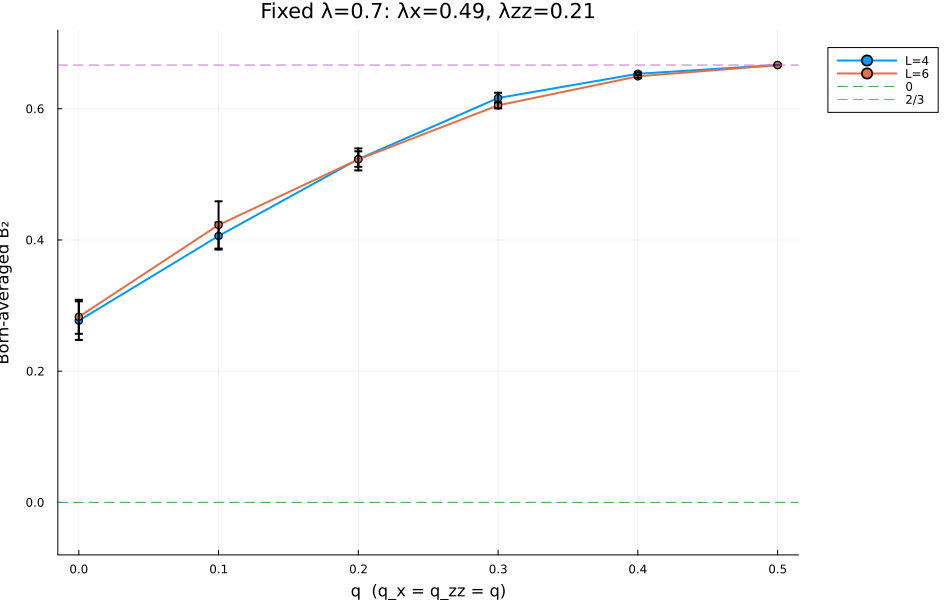

In [15]:

# ============================================================
# Plot proposal-averaged B2 versus q
# ============================================================

function plot_binder_scan(
    summary::DataFrame;
    title_suffix::AbstractString="",
)
    nrow(summary) > 0 || error("The summary table is empty.")

    p = plot(
        xlabel="q  (q_x = q_zz = q)",
        ylabel="Born-averaged B₂",
        title="Fixed λ=0.7: λx=0.49, λzz=0.21" * title_suffix,
        legend=:outertopright,
        size=(950, 600),
        ylims=(-0.08, 0.72),
    )

    for group in groupby(summary, :L)
        data = sort(DataFrame(group), :q)

        plot!(
            p,
            data.q,
            data.B2;
            yerror=data.B2_bootstrap_se,
            marker=:circle,
            linewidth=2,
            label="L=$(first(data.L))",
        )
    end

    hline!(p, [0.0]; linestyle=:dash, label="0")
    hline!(p, [2 / 3]; linestyle=:dash, label="2/3")

    return p
end

if nrow(active_scan.summary) > 0
    binder_plot = plot_binder_scan(active_scan.summary)
    display(binder_plot)
end


In [20]:

# ============================================================
# Quick and production configurations
# ============================================================

empty_scan = (
    summary=DataFrame(),
    trials=DataFrame(),
)

quick_scan = empty_scan

if RUN_QUICK_SCAN
    quick_scan = scan_fixed_lambda(
        [12,16],
        collect(0.0:0.10:0.50);
        ntrials=8,
        T_max_factor=2,
        maxdim=256,
        cutoff=1e-12,
        obs_maxdim_factor=4,
        obs_cutoff=1e-13,
        seed=11072,
        nboot=300,
        verbose=true,
    )

    display(quick_scan.summary)
end

production_scan = empty_scan

if RUN_PRODUCTION_SCAN
    # Start coarse. Refine q only after locating a possible crossing region.
    production_scan = scan_fixed_lambda(
        [6, 8, 10, 12, 14, 16],
        collect(0.00:0.01:0.50);
        ntrials=300,
        T_max_factor=6,
        maxdim=512,
        cutoff=1e-12,
        obs_maxdim_factor=4,
        obs_cutoff=1e-14,
        seed=20260710,
        nboot=3000,
        verbose=true,
    )

    display(production_scan.summary)
end

active_scan =
    nrow(production_scan.summary) > 0 ?
    production_scan : quick_scan


[1/12] L=12, q=0.00000, lambda=0.7, lambda_x=0.49, lambda_zz=0.21, q_x=q_zz=q
[2/12] L=12, q=0.10000, lambda=0.7, lambda_x=0.49, lambda_zz=0.21, q_x=q_zz=q
[3/12] L=12, q=0.20000, lambda=0.7, lambda_x=0.49, lambda_zz=0.21, q_x=q_zz=q
[4/12] L=12, q=0.30000, lambda=0.7, lambda_x=0.49, lambda_zz=0.21, q_x=q_zz=q
[5/12] L=12, q=0.40000, lambda=0.7, lambda_x=0.49, lambda_zz=0.21, q_x=q_zz=q
[6/12] L=12, q=0.50000, lambda=0.7, lambda_x=0.49, lambda_zz=0.21, q_x=q_zz=q
[7/12] L=16, q=0.00000, lambda=0.7, lambda_x=0.49, lambda_zz=0.21, q_x=q_zz=q
[8/12] L=16, q=0.10000, lambda=0.7, lambda_x=0.49, lambda_zz=0.21, q_x=q_zz=q
[9/12] L=16, q=0.20000, lambda=0.7, lambda_x=0.49, lambda_zz=0.21, q_x=q_zz=q
[10/12] L=16, q=0.30000, lambda=0.7, lambda_x=0.49, lambda_zz=0.21, q_x=q_zz=q
[11/12] L=16, q=0.40000, lambda=0.7, lambda_x=0.49, lambda_zz=0.21, q_x=q_zz=q
[12/12] L=16, q=0.50000, lambda=0.7, lambda_x=0.49, lambda_zz=0.21, q_x=q_zz=q


Row,L,lambda,delta,lambda_x,lambda_zz,q,q_x,q_zz,boundary,T_max,ntrials,n_valid,n_invalid,seed,maxdim,cutoff,obs_maxdim,obs_cutoff,B2,B2_bootstrap_se,B2_ci_low,B2_ci_high,B2_trial_std,B2_ratio_of_mean_moments,M2_mean,M4_mean,purity_mean,purity_std,max_interphysical_linkdim,max_trace_error
,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,String,Int64,Int64,Int64,Int64,Int64,Int64,Float64,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Int64,Float64
1,12,0.7,0.7,0.49,0.21,0.0,0.0,0.0,open,24,8,8,0,1212072,256,1.0e-12,1024,1.0e-13,0.117998,0.0111334,0.0974535,0.142207,0.0333435,0.111716,0.124532,0.041327,1.00003,6.39139e-5,68,2.22045e-16
2,12,0.7,0.7,0.49,0.21,0.1,0.1,0.1,open,24,8,8,0,1213072,256,1.0e-12,1024,1.0e-13,0.262012,0.0382316,0.202414,0.346448,0.115713,0.266951,0.252197,0.139873,0.0836156,0.0447966,71,2.22045e-16
3,12,0.7,0.7,0.49,0.21,0.2,0.2,0.2,open,24,8,8,0,1214072,256,1.0e-12,1024,1.0e-13,0.433404,0.0352595,0.366432,0.502037,0.103352,0.446265,0.439152,0.320371,0.011162,0.00578538,65,3.33067e-16
4,12,0.7,0.7,0.49,0.21,0.3,0.3,0.3,open,24,8,8,0,1215072,256,1.0e-12,1024,1.0e-13,0.570358,0.0100252,0.553022,0.590571,0.0304573,0.572096,0.689015,0.609432,0.00310691,0.000825312,45,2.22045e-16
5,12,0.7,0.7,0.49,0.21,0.4,0.4,0.4,open,24,8,8,0,1216072,256,1.0e-12,1024,1.0e-13,0.654792,0.00180318,0.651361,0.658097,0.00539121,0.654859,0.948718,0.931949,0.00147883,0.000103201,28,2.22045e-16
6,12,0.7,0.7,0.49,0.21,0.5,0.5,0.5,open,24,8,8,0,1217072,256,1.0e-12,1024,1.0e-13,0.666667,4.02505e-16,0.666667,0.666667,1.24481e-15,0.666667,1.0,1.0,0.00137718,0.000116243,4,2.22045e-16
7,16,0.7,0.7,0.49,0.21,0.0,0.0,0.0,open,32,8,8,0,1618072,256,1.0e-12,1024,1.0e-13,0.0907558,0.0110127,0.0741756,0.113026,0.0324214,0.0843176,0.0944435,0.0245025,1.00001,9.59141e-6,74,2.22045e-16
8,16,0.7,0.7,0.49,0.21,0.1,0.1,0.1,open,32,8,8,0,1619072,256,1.0e-12,1024,1.0e-13,0.287147,0.0306563,0.235559,0.348452,0.0966347,0.288612,0.225858,0.108867,0.0232548,0.0152563,93,2.22045e-16
9,16,0.7,0.7,0.49,0.21,0.2,0.2,0.2,open,32,8,8,0,1620072,256,1.0e-12,1024,1.0e-13,0.4232,0.0339416,0.361504,0.487708,0.106936,0.43573,0.39761,0.267623,0.00185635,0.00125358,74,2.22045e-16


(summary = 12×30 DataFrame
 Row │ L      lambda   delta    lambda_x  lambda_zz  q        q_x      q_zz    ⋯
     │ Int64  Float64  Float64  Float64   Float64    Float64  Float64  Float64 ⋯
─────┼──────────────────────────────────────────────────────────────────────────
   1 │    12      0.7      0.7      0.49       0.21      0.0      0.0      0.0 ⋯
   2 │    12      0.7      0.7      0.49       0.21      0.1      0.1      0.1
   3 │    12      0.7      0.7      0.49       0.21      0.2      0.2      0.2
   4 │    12      0.7      0.7      0.49       0.21      0.3      0.3      0.3
   5 │    12      0.7      0.7      0.49       0.21      0.4      0.4      0.4 ⋯
   6 │    12      0.7      0.7      0.49       0.21      0.5      0.5      0.5
   7 │    16      0.7      0.7      0.49       0.21      0.0      0.0      0.0
   8 │    16      0.7      0.7      0.49       0.21      0.1      0.1      0.1
   9 │    16      0.7      0.7      0.49       0.21      0.2      0.2      0.2 ⋯
  10 │    16 

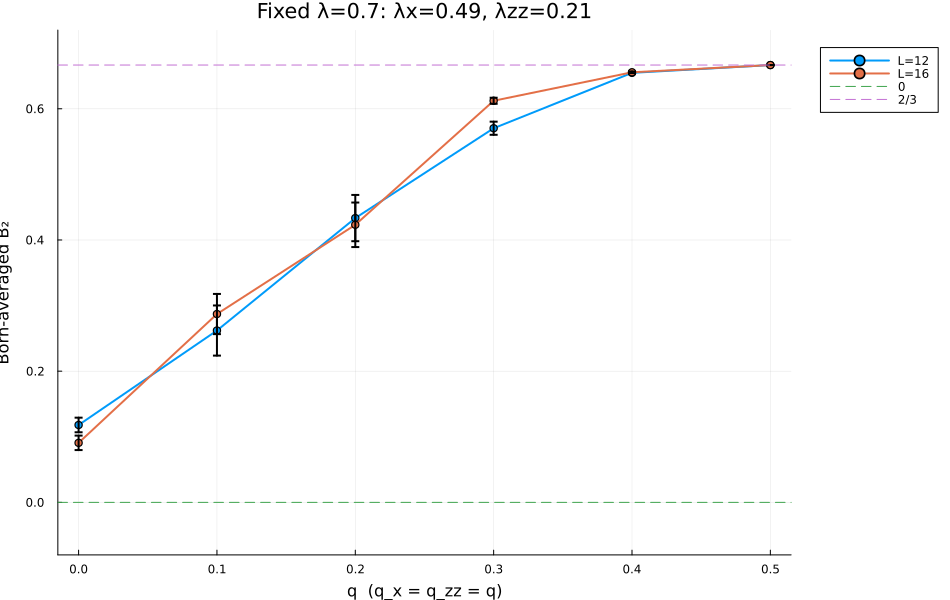

In [21]:

# ============================================================
# Plot proposal-averaged B2 versus q
# ============================================================

function plot_binder_scan(
    summary::DataFrame;
    title_suffix::AbstractString="",
)
    nrow(summary) > 0 || error("The summary table is empty.")

    p = plot(
        xlabel="q  (q_x = q_zz = q)",
        ylabel="Born-averaged B₂",
        title="Fixed λ=0.7: λx=0.49, λzz=0.21" * title_suffix,
        legend=:outertopright,
        size=(950, 600),
        ylims=(-0.08, 0.72),
    )

    for group in groupby(summary, :L)
        data = sort(DataFrame(group), :q)

        plot!(
            p,
            data.q,
            data.B2;
            yerror=data.B2_bootstrap_se,
            marker=:circle,
            linewidth=2,
            label="L=$(first(data.L))",
        )
    end

    hline!(p, [0.0]; linestyle=:dash, label="0")
    hline!(p, [2 / 3]; linestyle=:dash, label="2/3")

    return p
end

if nrow(active_scan.summary) > 0
    binder_plot = plot_binder_scan(active_scan.summary)
    display(binder_plot)
end


In [16]:

# ============================================================
# Pairwise finite-size crossing estimates at fixed lambda
# ============================================================

function pairwise_linear_crossings(
    summary::DataFrame,
    L1::Int,
    L2::Int,
)
    first_size = select(
        filter(:L => ==(L1), summary),
        :q,
        :B2 => :B2_1,
    )

    second_size = select(
        filter(:L => ==(L2), summary),
        :q,
        :B2 => :B2_2,
    )

    joined = sort(
        innerjoin(first_size, second_size; on=:q),
        :q,
    )

    nrow(joined) >= 2 || return Float64[]

    crossings = Float64[]

    for i in 1:(nrow(joined) - 1)
        x1, x2 = joined.q[i], joined.q[i + 1]
        d1 = joined.B2_1[i] - joined.B2_2[i]
        d2 = joined.B2_1[i + 1] - joined.B2_2[i + 1]

        if d1 == 0
            push!(crossings, x1)
        elseif d1 * d2 < 0
            crossing =
                x1 - d1 * (x2 - x1) / (d2 - d1)
            push!(crossings, crossing)
        end
    end

    return unique(crossings)
end

function crossing_summary(summary::DataFrame)
    sizes = sort(unique(summary.L))
    rows = NamedTuple[]

    for i in 1:(length(sizes) - 1)
        L1, L2 = sizes[i], sizes[i + 1]
        crossings =
            pairwise_linear_crossings(summary, L1, L2)

        if isempty(crossings)
            push!(rows, (
                L1=L1,
                L2=L2,
                crossing_index=0,
                q_crossing=NaN,
            ))
        else
            for (index, crossing) in enumerate(crossings)
                push!(rows, (
                    L1=L1,
                    L2=L2,
                    crossing_index=index,
                    q_crossing=crossing,
                ))
            end
        end
    end

    return DataFrame(rows)
end

if nrow(active_scan.summary) > 0
    crossings = crossing_summary(active_scan.summary)
    display(crossings)
end


Row,L1,L2,crossing_index,q_crossing
,Int64,Int64,Int64,Float64
1,4,6,1,0.197181
2,4,6,2,0.5



## Critical scaling scaffold

Once a stable crossing estimate \(q_c\) is available, test

\[
\overline{B_2}(q,L)
=
F\!\left[(q-q_c)L^{1/\nu}\right].
\]

Do not infer \(q_c\) from a single size pair. First establish convergence in
\(T/L\), MPS bond dimension, cutoff, and trajectory count.


In [17]:

# ============================================================
# Scaling-collapse plot for user-supplied q_c and nu
# ============================================================

function plot_scaling_collapse(
    summary::DataFrame;
    q_c::Float64,
    nu::Float64,
)
    nrow(summary) > 0 || error("The summary table is empty.")
    nu > 0 || error("nu must be positive.")

    p = plot(
        xlabel="(q - q_c) L^(1/nu)",
        ylabel="Born-averaged B₂",
        title=@sprintf(
            "B₂ scaling collapse: q_c=%.5f, ν=%.4f",
            q_c,
            nu,
        ),
        legend=:best,
    )

    for group in groupby(summary, :L)
        data = sort(DataFrame(group), :q)
        L = first(data.L)
        scaled_x = (data.q .- q_c) .* L^(1 / nu)

        plot!(
            p,
            scaled_x,
            data.B2;
            yerror=data.B2_bootstrap_se,
            marker=:circle,
            linewidth=2,
            label="L=$L",
        )
    end

    return p
end

# After obtaining a stable crossing and exponent estimate:
# display(plot_scaling_collapse(active_scan.summary; q_c=0.30, nu=1.5))


plot_scaling_collapse (generic function with 1 method)

In [18]:

# ============================================================
# Convergence checks
# ============================================================

function convergence_table(
    L::Int,
    q::Float64;
    T_factors=(2, 4, 6),
    maxdims=(128, 256, 512),
    ntrials::Int=60,
    seed::Int=314159,
)
    rows = NamedTuple[]

    for T_factor in T_factors
        for maxdim in maxdims
            result = run_fixed_lambda_point(
                L,
                q;
                ntrials=ntrials,
                T_max=T_factor * L,
                maxdim=maxdim,
                cutoff=DYN_CUTOFF,
                obs_maxdim=OBS_MAXDIM_FACTOR * maxdim,
                obs_cutoff=OBS_CUTOFF,
                seed=seed + 1000 * T_factor + maxdim,
                nboot=500,
            )

            push!(rows, (
                L=L,
                lambda=FIXED_LAMBDA,
                lambda_x=FIXED_LAMBDA_X,
                lambda_zz=FIXED_LAMBDA_ZZ,
                q=q,
                T_max=T_factor * L,
                maxdim=maxdim,
                B2=result.summary.B2,
                B2_se=result.summary.B2_bootstrap_se,
                B2_ratio_of_mean_moments=
                    result.summary.B2_ratio_of_mean_moments,
                M2_mean=result.summary.M2_mean,
                M4_mean=result.summary.M4_mean,
                purity_mean=result.summary.purity_mean,
                max_trace_error=result.summary.max_trace_error,
                max_interphysical_linkdim=
                    result.summary.max_interphysical_linkdim,
            ))
        end
    end

    return DataFrame(rows)
end

# Example near a candidate crossing:
# display(convergence_table(10, 0.30; ntrials=80))


convergence_table (generic function with 1 method)

In [19]:

# ============================================================
# Diagnostics and export
# ============================================================

function diagnose_scan(scan)
    summary = scan.summary
    nrow(summary) > 0 || error("The scan is empty.")

    println(
        "Maximum trace error: ",
        maximum(summary.max_trace_error),
    )

    println(
        "Maximum inter-physical-site link dimension: ",
        maximum(summary.max_interphysical_linkdim),
    )

    println(
        "Maximum |proposal B2 - ratio-of-mean-moments diagnostic|: ",
        maximum(
            abs.(
                summary.B2 .-
                summary.B2_ratio_of_mean_moments
            )
        ),
    )

    if any(.!isapprox.(summary.lambda, FIXED_LAMBDA; atol=1e-14))
        error("Parameter violation: lambda is not fixed at 0.7.")
    end

    if any(.!isapprox.(summary.lambda_x, FIXED_LAMBDA_X; atol=1e-14))
        error("Parameter violation: lambda_x is not 0.49.")
    end

    if any(.!isapprox.(summary.lambda_zz, FIXED_LAMBDA_ZZ; atol=1e-14))
        error("Parameter violation: lambda_zz is not 0.21.")
    end

    if any(summary.q_x .!= summary.q_zz)
        error("Proposal violation: q_x and q_zz are not equal.")
    end

    if any(summary.q .> 0.5) || any(summary.q .< 0.0)
        error("Proposal violation: q is outside [0, 1/2].")
    end

    println("Parameterization checks passed.")
end

function export_scan(
    scan;
    prefix::AbstractString="lambda0p7_proposal_B2",
)
    nrow(scan.summary) > 0 || error("The scan is empty.")

    stamp = Dates.format(now(), "yyyymmdd_HHMMSS")
    summary_path = "$(prefix)_summary_$(stamp).csv"
    trials_path = "$(prefix)_trials_$(stamp).csv"
    plot_path = "$(prefix)_$(stamp).png"

    CSV.write(summary_path, scan.summary)
    CSV.write(trials_path, scan.trials)

    p = plot_binder_scan(scan.summary)
    savefig(p, plot_path)

    println("Saved: ", summary_path)
    println("Saved: ", trials_path)
    println("Saved: ", plot_path)

    return (
        summary=summary_path,
        trials=trials_path,
        plot=plot_path,
    )
end

if nrow(active_scan.summary) > 0
    diagnose_scan(active_scan)
end

# Example:
# export_scan(active_scan)


Maximum trace error: 2.220446049250313e-16
Maximum inter-physical-site link dimension: 57
Maximum |proposal B2 - ratio-of-mean-moments diagnostic|: 0.01413084782996371
Parameterization checks passed.



## Research-proposal checklist for the \(\lambda=0.7\) slice

1. **Correct fixed slice**
   \[
   \lambda=0.7,\quad \delta=0.7,\quad
   \lambda_x=0.49,\quad \lambda_{zz}=0.21,\quad
   q_x=q_{zz}=q.
   \]

2. **All four layers present**  
   Weak \(X\), \(X\) dephasing, weak \(ZZ\), and \(ZZ\) dephasing must all
   be applied once per full time step.

3. **Exact conditional Born sampling**  
   Construct both Kraus branches for every measured site or bond, normalize
   their numerical weights, and sample conditionally.

4. **Correct nonlinear observable**  
   Use \(Z_iZ_i'\) replica-overlap correlations, not a bra-only
   magnetization.

5. **Correct averaging order**  
   Compute \(B_2(m)\) for each trajectory, then average \(B_2(m)\).

6. **Steady state**  
   Increase \(T/L\) until \(B_2\), \(M_2\), \(M_4\), and purity stop drifting.

7. **MPS convergence**  
   Compare multiple `maxdim` and `cutoff` values. The additional weak \(ZZ\)
   layer may require larger bond dimensions than the right boundary.

8. **Finite-size evidence**  
   Require stable crossings for several adjacent size pairs.

9. **Compare diagnostics**  
   Track trace error, maximum link dimension, invalid trajectories, and the
   difference between the proposal average and the ratio-of-mean-moments
   diagnostic.

10. **Map the phase boundary**  
    Repeat for additional fixed \(\lambda\) values after validating this slice.
